In [1]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
def select_device():
    return 'cuda' if torch.cuda.is_available() else ('mps' if torch.mps.is_available() else 'cpu')

In [4]:
N = 10.0           # range [-N, N]
num_samples = 1000    # how many pairs we want
dtype = torch.float32

X = (2 * torch.rand(num_samples, 2, dtype=dtype) - 1) * N
Y = (X[:, 0] * X[:, 1]).unsqueeze(1)

print("X:\n", X)
print("Y:\n", Y)

X:
 tensor([[ 2.0466e+00,  6.3292e+00],
        [ 3.7346e+00, -2.4057e-01],
        [-2.6059e-03,  1.5601e+00],
        ...,
        [ 5.6187e+00, -7.9565e-02],
        [-4.5690e+00, -3.2198e+00],
        [-5.5931e+00, -7.2837e+00]])
Y:
 tensor([[ 1.2953e+01],
        [-8.9845e-01],
        [-4.0656e-03],
        [ 1.5050e+01],
        [-8.1143e+01],
        [ 8.0998e+00],
        [ 1.5016e+01],
        [ 1.5387e+01],
        [-2.3569e+01],
        [ 3.8088e+01],
        [ 1.5204e+01],
        [ 2.1006e+01],
        [ 1.1731e+01],
        [ 1.2897e+01],
        [ 3.1461e+00],
        [-7.3743e+01],
        [ 4.8567e+00],
        [-4.6760e+00],
        [ 1.5101e+01],
        [-1.5227e+01],
        [ 2.2946e-01],
        [-2.9945e+01],
        [-3.0777e+01],
        [ 2.9978e+01],
        [ 6.0423e+01],
        [-8.5758e+00],
        [-2.5013e+01],
        [ 6.9368e+01],
        [ 1.3086e+00],
        [ 1.9899e+00],
        [-3.8752e+00],
        [-3.6843e+01],
        [-2.2033e+00],
   

In [5]:
device = select_device()
X = X.to(device)
Y = Y.to(device)

In [6]:
class MyNeuralNet(nn.Module):
    def __init__(self, n_neurons: int):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2, n_neurons)
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Linear(n_neurons,1)
    def forward(self, x):
        x = self.input_to_hidden_layer(x)
        x = self.hidden_layer_activation(x)
        x = self.hidden_to_output_layer(x)
        return x

In [11]:
def testNN(net, loss_func, opt):
    print(f"initial loss: {loss_func(net(X), Y)}")

    loss_history = []
    for _ in range(300):
        opt.zero_grad()
        loss_value = loss_func(mynet(X),Y)
        loss_value.backward()
        opt.step()
        loss_history.append(loss_value.item())

    print(f"final_loss: {loss_history[-1]}")

    plt.plot(loss_history)
    plt.title('Loss variation over increasing epochs')
    plt.xlabel('epochs')
    plt.ylabel('loss value')

initial loss: 1094.935546875
final_loss: 43.144805908203125


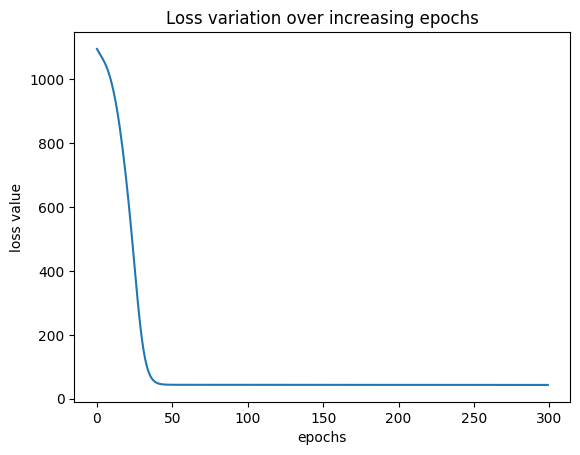

In [14]:
from torch.optim import SGD
mynet = MyNeuralNet(8).to(device)
opt = SGD(mynet.parameters(), lr = 0.001)

testNN(mynet, nn.MSELoss(), opt)

initial loss: 1055.145751953125
final_loss: 43.19121551513672


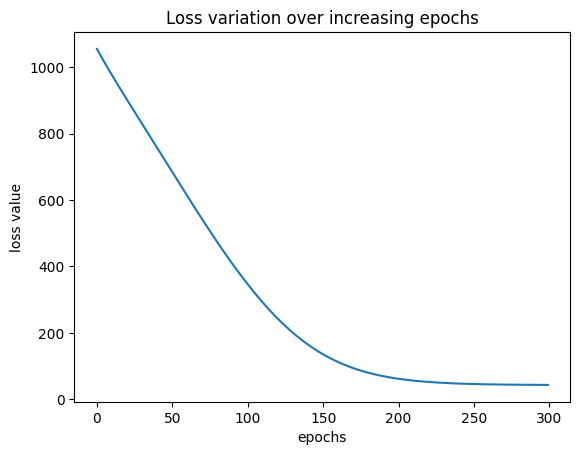

In [24]:
mynet = MyNeuralNet(50).to(device)
opt = SGD(mynet.parameters(), lr = 0.0001)

testNN(mynet, nn.MSELoss(), opt)

initial loss: 1111.4307861328125
final_loss: 42.830902099609375


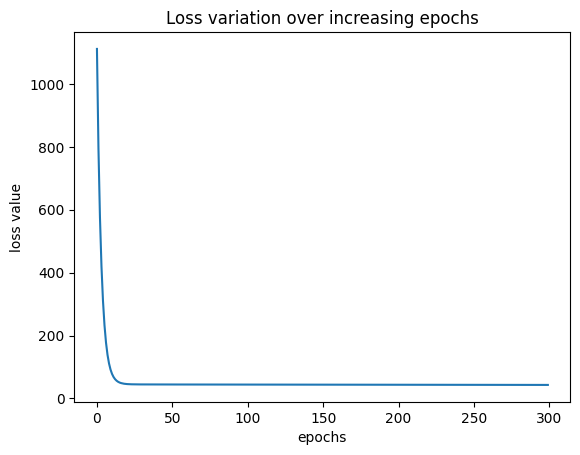

In [23]:
mynet = MyNeuralNet(2000).to(device)
opt = SGD(mynet.parameters(), lr = 0.0001)

testNN(mynet, nn.MSELoss(), opt)